In [4]:
# conda install -c conda-forge openc

ModuleNotFoundError: No module named 'cv2'

In [18]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# importing necessary library for dl
from glob import glob
import tensorflow as tf
import cv2
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, GlobalMaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
# from keras.utils.np_utils import to_categorical # convert to one-hot-encoding
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow import keras

ModuleNotFoundError: No module named 'cv2'

In [3]:
data_train_path="/Users/mac/Downloads/Vegetable Images 2/train"
data_test_path="/Users/mac/Downloads/Vegetable Images 2/test"
data_val_path="/Users/mac/Downloads/Vegetable Images 2/validation"

In [4]:
img_width=180
img_height=180

In [5]:
data_train=tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width,img_height),
    batch_size=32,
    validation_split=False
)

Found 15000 files belonging to 15 classes.


In [6]:
data_cat=data_train.class_names
data_cat

['Bean',
 'Bitter_Gourd',
 'Bottle_Gourd',
 'Brinjal',
 'Broccoli',
 'Cabbage',
 'Capsicum',
 'Carrot',
 'Cauliflower',
 'Cucumber',
 'Papaya',
 'Potato',
 'Pumpkin',
 'Radish',
 'Tomato']

In [175]:
data_val=tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    shuffle=False,
    image_size=(img_width,img_height),
    batch_size=32,
    validation_split=False
)

Found 3000 files belonging to 15 classes.


In [177]:
data_test=tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    shuffle=True,
    image_size=(img_width,img_height),
    batch_size=32,
    validation_split=False
)

Found 3000 files belonging to 15 classes.


2023-03-08 09:59:40.364350: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


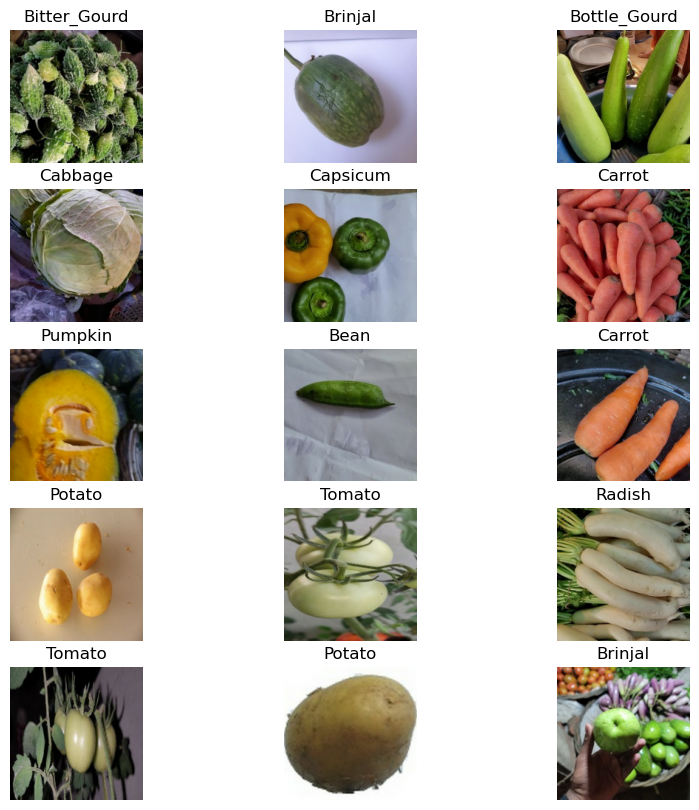

In [179]:
plt.figure(figsize=(10,10))
for image , labels in data_train.take(1):
    for i in range(15):
        plt.subplot(5,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [181]:
from tensorflow.keras import Sequential

In [183]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [185]:
model=Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(15,3,padding='same' , activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same' , activation='relu'),
    layers.MaxPooling2D(), 
    layers.Conv2D(64,3,padding='same' , activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
])

In [187]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [189]:
epochs_size=10

history=model.fit(data_train,validation_data=data_val,epochs=epochs_size,)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 457s 967ms/step - accuracy: 0.5078 - loss: 1.5608 - val_accuracy: 0.8640 - val_loss: 0.4448
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 449s 957ms/step - accuracy: 0.8947 - loss: 0.3484 - val_accuracy: 0.8653 - val_loss: 0.4613
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 538s 1s/step - accuracy: 0.9464 - loss: 0.1820 - val_accuracy: 0.8917 - val_loss: 0.3768
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 444s 946ms/step - accuracy: 0.9546 - loss: 0.1381 - val_accuracy: 0.9230 - val_loss: 0.2951
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 428s 913ms/step - accuracy: 0.9728 - loss: 0.0849 - val_accuracy: 0.9287 - val_loss: 0.2586
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 459s 979ms/step - accuracy: 0.9814 - loss: 0.0602 - val_accuracy: 0.9367 - val_loss: 0.2428
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.9751 - loss: 0.0708 - val_accuracy: 0.8777 - val_loss: 0.6155
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.9743 - loss: 0.

Text(0.5, 1.0, 'loss')

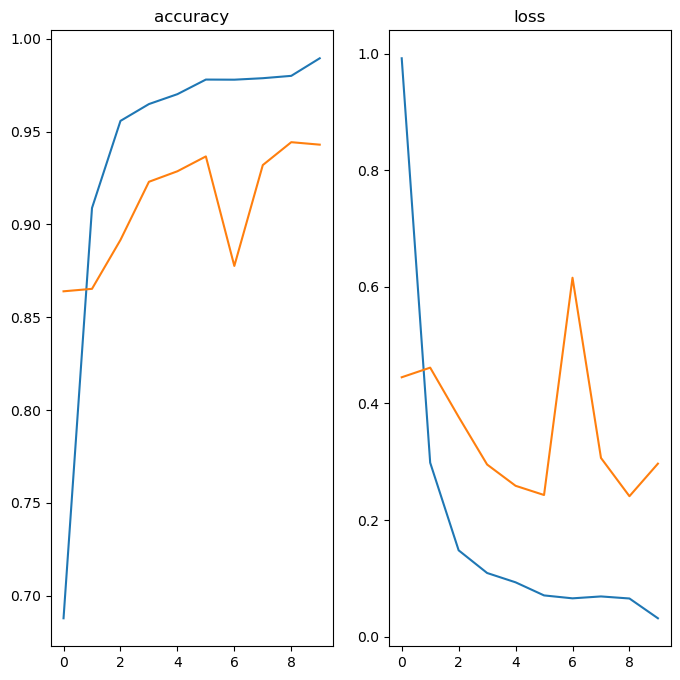

In [190]:
epochs_range=range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label='training accuracy')
plt.plot(epochs_range,history.history['val_accuracy'],label='validation accuracy')
plt.title('accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label='training loss')
plt.plot(epochs_range,history.history['val_loss'],label='validation loss')
plt.title('loss')

In [191]:
image='pumpkin.jpg'
image=tf.keras.utils.load_img(image, target_size=(img_height,img_width))
img_arr=tf.keras.utils.array_to_img(image)
img_bat=tf.expand_dims(img_arr,0)

In [192]:
predict=model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


In [193]:
score=tf.nn.softmax(predict)

In [194]:
print('veg/fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))

veg/fruit in image is Pumpkin with accuracy of 100.00


In [195]:
model.save('image_classify.keras')